# Notebook 16 — Adversarial Market Generation

This notebook demonstrates:
1. Initializing the WGAN-GP Generator and Discriminator for returns/volatility paths.
2. Formulating the four differentiable stylized facts losses (GPD tail gap, ACF, Leverage correlation, CFVC).
3. Running the zero-sum minimax robust training loop between the generator and the hedging policy.
4. Visualizing synthetic return paths and validating their stylized facts properties.

In [1]:
import os
import sys

# Ensure src is in python path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from hedging.deep_hedging import HedgingPolicy
from hedging.adversarial_market import (
    WGAN_GP_Generator,
    WGAN_GP_Discriminator,
    train_robust_minimax_hedger
)

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


## 1. Prepare Mock Real Data

We generate a mock real market returns dataset to act as the target distribution for stylized facts alignment.

In [2]:
torch.manual_seed(42)
latent_dim = 10
seq_len = 50
N_paths = 512

# Create mock real returns with fat tails and autocorrelation
real_returns = torch.randn(N_paths, seq_len, device=device) * 0.01

# target ACF
real_acf = torch.linspace(0.15, 0.02, 20, device=device)
real_leverage = -0.15
real_cfvc_matrix = torch.eye(4, device=device)

print(f"Mock real returns shape: {real_returns.shape}")



Mock real returns shape: torch.Size([512, 50])


## 2. Initialize Networks

We initialize the Generator, Discriminator, and LSTM Hedging Policy.

In [3]:
generator = WGAN_GP_Generator(latent_dim=latent_dim, seq_len=seq_len, hidden_dim=16).to(device)
discriminator = WGAN_GP_Discriminator(seq_len=seq_len, hidden_dim=16).to(device)
policy = HedgingPolicy(input_dim=5, hidden_dim=16, output_dim=2).to(device) # d = 2 instruments

print("Networks successfully initialized.")



Networks successfully initialized.


## 3. Run Minimax Adversarial Training

We run the robust minimax optimization loop for a few epochs.

In [4]:
print("Starting robust minimax training loop...")
train_robust_minimax_hedger(
    real_returns=real_returns,
    real_acf=real_acf,
    real_leverage=real_leverage,
    real_cfvc_matrix=real_cfvc_matrix,
    generator=generator,
    discriminator=discriminator,
    policy=policy,
    epochs=10,
    critic_steps=2,
    minimax_coeff=0.01,
    device=device
)



Starting robust minimax training loop...


/home/execorn/programming/derivatives/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:882: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:370.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 01 | Disc: 9.7510 | Gen: -12469.4878 | Hedge: 1465926.5000


Epoch 05 | Disc: 9.5432 | Gen: -817.1392 | Hedge: 83038.5469


Epoch 10 | Disc: 9.0920 | Gen: -114.3350 | Hedge: 11666.9136
Minimax Deep Hedging Training COMPLETE.


## 4. Generate Synthetic Paths and Validate Stylized Facts

We extract return paths from the generator and plot them.

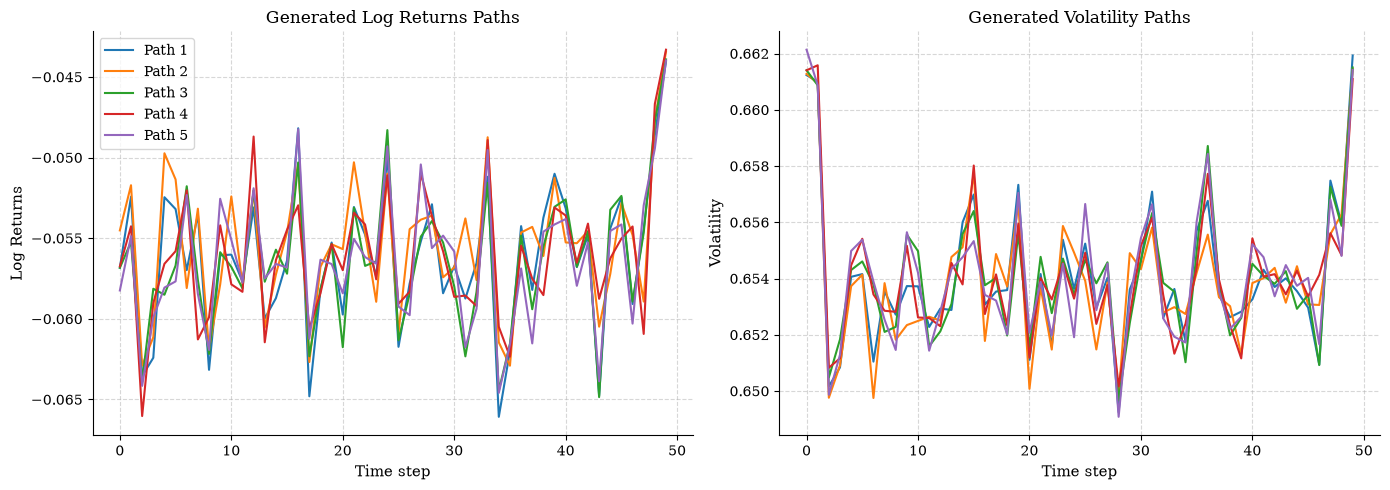

In [5]:
generator.eval()
with torch.no_grad():
    z = torch.randn(5, latent_dim, device=device)
    fake_samples = generator(z)
    fake_ret = fake_samples[:, 0, :].cpu().numpy()
    fake_vol = fake_samples[:, 1, :].cpu().numpy()

# Plot generated log returns and volatility
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i in range(5):
    ax1.plot(fake_ret[i], label=f"Path {i+1}")
ax1.set_xlabel("Time step")
ax1.set_ylabel("Log Returns")
ax1.set_title("Generated Log Returns Paths")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend()

for i in range(5):
    ax2.plot(fake_vol[i])
ax2.set_xlabel("Time step")
ax2.set_ylabel("Volatility")
ax2.set_title("Generated Volatility Paths")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

